In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [3]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [4]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [5]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.296837,-0.278900,1.304800,-0.241195,0.727826,0.193254,-0.197587,0.649184,-0.449889,-0.003667,...,0.790613,0.466047,1.248569,-0.241779,-0.001937,-0.016337,-0.446484,-0.339881,0.0,No Anomaly
1,-1.172400,-1.238202,-1.016240,1.476917,-2.191765,-1.254831,2.093386,-1.500323,0.325552,0.010862,...,-2.040357,-1.199394,-0.842821,-0.830572,-0.002550,-0.024644,-0.044448,-0.501749,0.0,No Anomaly
2,-0.322193,-0.310839,0.184832,3.210709,0.635948,0.452825,-0.137246,0.649184,-0.240103,-0.001462,...,0.547117,2.002424,0.164526,1.680987,-0.001927,-0.016811,-0.179078,1.395928,0.0,No Anomaly
3,-0.132920,-0.162163,1.344982,-0.241195,0.337600,0.151805,0.432062,0.626321,-0.441726,-0.003638,...,0.335267,0.446221,1.385320,-0.305772,-0.001754,-0.013701,-0.496409,-0.332040,0.0,No Anomaly
4,-0.927888,-0.866524,-0.821689,-2.037837,0.486443,-2.167966,0.651564,-0.493934,0.149541,-0.003213,...,1.690792,-1.010078,-0.754378,-0.637653,-0.002704,-0.022672,0.231300,-0.769605,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,-0.175123,-0.140101,0.309762,0.459999,0.437272,0.351762,-0.918067,0.702521,-0.292050,-0.003292,...,0.355748,0.830122,0.193165,0.616160,-0.001939,-0.014219,-0.205651,0.496239,7.0,Sharp Water Increase (Circuit)
312021,-0.161709,-0.128592,-0.403209,-0.360944,0.089312,0.309662,-1.008307,0.679958,-0.094129,-0.003780,...,-0.047678,0.438871,-0.492321,0.845159,-0.001929,-0.013898,0.037364,0.806503,7.0,Sharp Water Increase (Circuit)
312022,-0.158827,-0.142787,0.564789,0.291949,0.283063,0.447366,-0.182039,0.741042,-0.325998,-0.003448,...,0.119139,0.790505,0.529696,0.349839,-0.001884,-0.014227,-0.316814,0.305259,7.0,Sharp Water Increase (Circuit)
312023,-0.320137,-0.342151,1.128326,-0.190532,0.166564,0.739368,1.996434,0.533313,-0.374118,-0.003483,...,-0.170820,0.387215,1.400472,-0.349320,-0.001823,-0.016689,-0.509788,-0.296223,7.0,Sharp Water Increase (Circuit)


In [6]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.339258,-0.296663,0.832423,-0.241195,0.685351,0.326253,0.146221,0.641799,-0.367886,-0.003658,...,0.671467,0.459643,0.835664,-0.070604,-0.002026,-0.016831,-0.362470,-0.173592,0.0,No Anomaly
1,-1.172072,-1.236445,-1.947671,-1.974987,-2.280258,-1.438486,0.406451,-1.522739,1.252527,0.002666,...,-2.055441,-1.611856,-1.894342,-0.873525,-0.002569,-0.024614,0.998860,-0.550071,0.0,No Anomaly
2,-1.172583,-1.241348,-1.952961,-0.249035,-2.158810,-1.274461,-2.560895,-1.522739,1.023573,0.007042,...,-1.990198,-1.418296,-2.023951,-0.231211,-0.002506,-0.024636,1.301091,0.193565,0.0,No Anomaly
3,-1.173636,-1.237807,-1.477705,-0.249035,-2.141195,-1.253476,0.828965,-1.637051,0.632766,0.009694,...,-1.979316,-1.517289,-1.402205,-1.014551,-0.002582,-0.024495,0.367283,-0.727593,12.0,Inlet Valve Malfunction
4,-0.332734,-0.257563,0.826198,1.484757,0.923321,-0.183577,-0.405097,0.573006,-0.380350,-0.002437,...,1.219922,1.148021,0.753872,0.487574,-0.002114,-0.016258,-0.325624,0.209035,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.177459,-1.248146,-1.447486,-0.249035,-2.052154,-1.180062,0.175330,-1.545602,0.565663,0.007504,...,-1.907779,-1.438095,-1.410425,-0.874651,-0.002504,-0.024668,0.390051,-0.574801,12.0,Inlet Valve Malfunction
7377,-0.344232,-0.303256,0.642152,-0.241195,0.737390,0.277473,-0.751903,0.626321,-0.355850,-0.003638,...,0.759670,0.446221,0.530495,0.073875,-0.002024,-0.016879,-0.281652,-0.061929,0.0,No Anomaly
7378,-1.175734,-1.248523,-2.241787,-0.249035,-2.240059,-1.347423,0.010922,-1.522015,1.944217,0.007028,...,-2.052452,-1.417669,-2.199598,0.095738,-0.002459,-0.024683,1.771030,0.596584,0.0,No Anomaly
7379,-0.189392,-0.192272,0.323089,1.484757,0.242942,0.385734,2.650825,0.657963,-0.194612,-0.002578,...,0.101352,1.244172,0.633977,0.639530,-0.001841,-0.014647,-0.346630,0.576985,0.0,No Anomaly


In [7]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
# anomaly_ids

In [8]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### K-Means

In [9]:
dataframe_data = dataframe_train_scaled.drop(columns=["description"])

kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

KMeans(n_clusters=14, random_state=42)

In [10]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 72980 times
1 occurs 43061 times
2 occurs 54008 times
3 occurs 28498 times
4 occurs 24169 times
5 occurs 1 times
6 occurs 1 times
7 occurs 1 times
8 occurs 22223 times
9 occurs 56773 times
10 occurs 10285 times
11 occurs 1 times
12 occurs 21 times
13 occurs 3 times


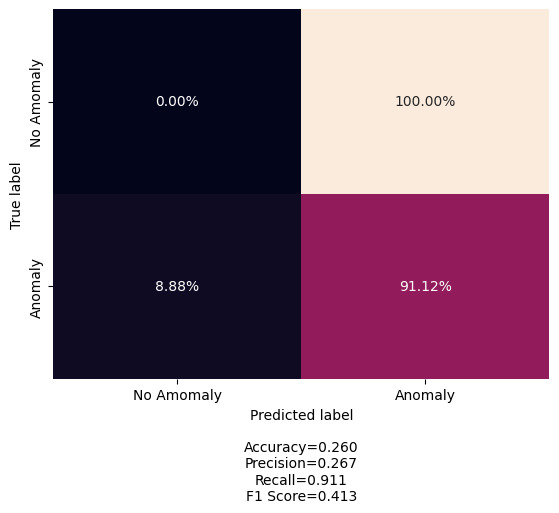

In [11]:
dataframe_data = dataframe_test_scaled.drop(columns=["anomaly", "description"])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_test_scaled.anomaly.values, kmeans_custom.predict(dataframe_data.values))),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [12]:
# plot.make_confusion_matrix(
#     confusion_matrix(dataframe_train_scaled.anomaly.values, kmeans_custom.labels_),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

### Isolation Forest

In [13]:
dataframe_X_train = dataframe_train_scaled.drop(columns=["anomaly", "description"])
dataframe_y_train = dataframe_train_scaled[["anomaly"]]
dataframe_X_test = dataframe_test_scaled.drop(columns=["anomaly", "description"])
dataframe_y_test = dataframe_test_scaled[["anomaly"]]

In [14]:
# dataframe_X = dataframe.drop(columns=["anomaly", "description"])
# dataframe_y = dataframe[["anomaly"]]

# X_train, X_test, y_train, y_test = train_test_split(
#                                                         dataframe_X.values, 
#                                                         dataframe_y.values.ravel(), 
#                                                         test_size=0.3, 
#                                                         random_state=SEED, 
#                                                         stratify=dataframe_y.values.ravel()
# )
# dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
# dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
# dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
# dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [15]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [16]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 3082 anomalies in test set.


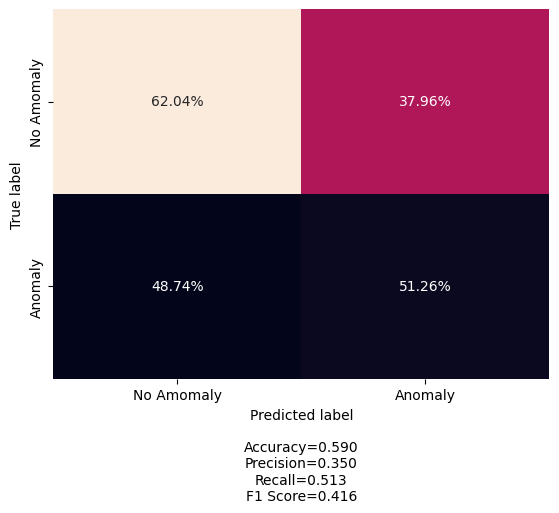

In [17]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [18]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [19]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 310 anomalies in test set.


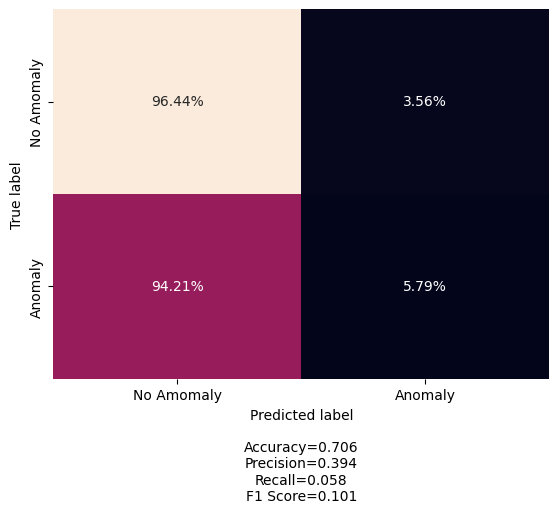

In [20]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)